Dataset Loading + Basic Understanding

In [ ]:
# =========================
# STEP 1 : LOAD DATASET
# =========================

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# =========================
# Import Libraries
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Dataset Paths
# =========================

train_path = "/content/drive/MyDrive/AI and Machine Learning/5. Movie Review Dataset/train_movie_review.csv"

val_path = "/content/drive/MyDrive/AI and Machine Learning/5. Movie Review Dataset/val_movie_review.csv"

test_path = "/content/drive/MyDrive/AI and Machine Learning/5. Movie Review Dataset/test_movie_review.csv"

# =========================
# Load Dataset
# =========================

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)



Mounted at /content/drive


TRAIN SHAPE : (35000, 3)
VALIDATION SHAPE : (5000, 3)
TEST SHAPE : (10000, 3)

================ TRAIN DATA =================
   Unnamed: 0                                             review  sentiment
0        3774  Having avoided seeing the movie in the cinema,...          0
1       48396  With this movie I was really hoping that the i...          0
2        1980  Raymond Burr stars as an attorney caught up in...          0
3        6703  A lot people get hung up on this films tag as ...          1
4       28168  I was a fan of Buffy and hoped it would come t...          0

TRAIN COLUMNS:
Index(['Unnamed: 0', 'review', 'sentiment'], dtype='object')

MISSING VALUES:
Unnamed: 0    0
review        0
sentiment     0
dtype: int64

DATASET INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  35000 non-null  int64 
 1   review      3500

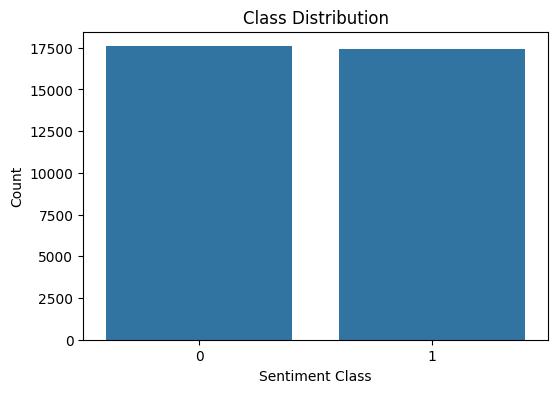

In [ ]:
# =========================
# Display Basic Information
# =========================

print("TRAIN SHAPE :", train_df.shape)
print("VALIDATION SHAPE :", val_df.shape)
print("TEST SHAPE :", test_df.shape)

print("\n================ TRAIN DATA =================")
print(train_df.head())

# =========================
# Check Column Names
# =========================

print("\nTRAIN COLUMNS:")
print(train_df.columns)


print("\nMISSING VALUES:")
print(train_df.isnull().sum())



print("\nDATASET INFO:")
print(train_df.info())

# =========================
# Class Distribution
# =========================

# Change 'label' if your target column has different name

label_column = 'sentiment'

print("\nCLASS DISTRIBUTION:")
print(train_df[label_column].value_counts())

# =========================
# Plot Class Distribution
# =========================

plt.figure(figsize=(6,4))

sns.countplot(x=train_df[label_column])

plt.title("Class Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Count")

plt.show()

STEP 2 CODE — FULL CLEANING PIPELINE

In [ ]:

# STEP 2 : TEXT CLEANING

# Install contractions library
!pip install contractions

# =========================
# Import Libraries
# =========================

import re
import nltk
import contractions

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download NLTK Resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


stop_words = set(stopwords.words('english'))

# Keep important negation words
negation_words = {'not', 'no', 'nor', 'never'}

stop_words = stop_words - negation_words

lemmatizer = WordNetLemmatizer()

# Text Cleaning Function
def clean_text(text):

    # Convert to string
    text = str(text)

    # Lowercase
    text = text.lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords + lemmatization
    cleaned_words = []

    for word in words:

        if word not in stop_words:

            lemma_word = lemmatizer.lemmatize(word)

            cleaned_words.append(lemma_word)

    # Join cleaned words
    cleaned_text = " ".join(cleaned_words)

    return cleaned_text

# Apply Cleaning
train_df['clean_review'] = train_df['review'].apply(clean_text)

val_df['clean_review'] = val_df['review'].apply(clean_text)

test_df['clean_review'] = test_df['review'].apply(clean_text)

# Show Results

print("\nORIGINAL REVIEW:\n")
print(train_df['review'][0])

print("\nCLEANED REVIEW:\n")
print(train_df['clean_review'][0])

# Check Cleaned Dataset


print("\nCLEANED DATASET SAMPLE:\n")

train_df[['review', 'clean_review', 'sentiment']].head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.3 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...



ORIGINAL REVIEW:

Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' - utter, utter cr**. I like ABBA, I like the songs, I have the old LPs. But this film is just terrible. The stage show looks like a bit of a musical, but this races along with songs hurriedly following one another, no characterisation, the dance numbers (which were heavily choreographed according to the extras on the DVD) are just thrown away with only half the bodies ever on screen, the dance chorus of north Europeans appear on a small Greek island at will, while the set and set up of numbers would have disgraced Cliff Richard's musicals in the sixties!Meryl (see me I'm acting)Streep can't even make her usual mugging effective in an over-the-top musical! Her grand piece - 'The Winner Takes It All' - is Meryl at the Met! Note to director - it should have been shot in stil

,review,clean_review,sentiment
0,"Having avoided seeing the movie in the cinema,...",avoided seeing movie cinema buying dvd wife xm...,0
1,With this movie I was really hoping that the i...,movie really hoping idea make hashed together ...,0
2,Raymond Burr stars as an attorney caught up in...,raymond burr star attorney caught murder best ...,0
3,A lot people get hung up on this films tag as ...,lot people get hung film tag childrens film ce...,1
4,I was a fan of Buffy and hoped it would come t...,fan buffy hoped would come proper end angel go...,0


STEP 3 — Text Visualization & Analysis

         Word  Frequency
0         not      83226
1       movie      69078
2        film      62962
3         one      36855
4        like      27684
5       would      21601
6        time      20566
7        good      19949
8   character      19147
9       story      16960
10         no      16907
11        get      16906
12       even      16894
13       make      16501
14        see      16431
15     really      15987
16      scene      14594
17       much      13169
18      could      13024
19       well      12927


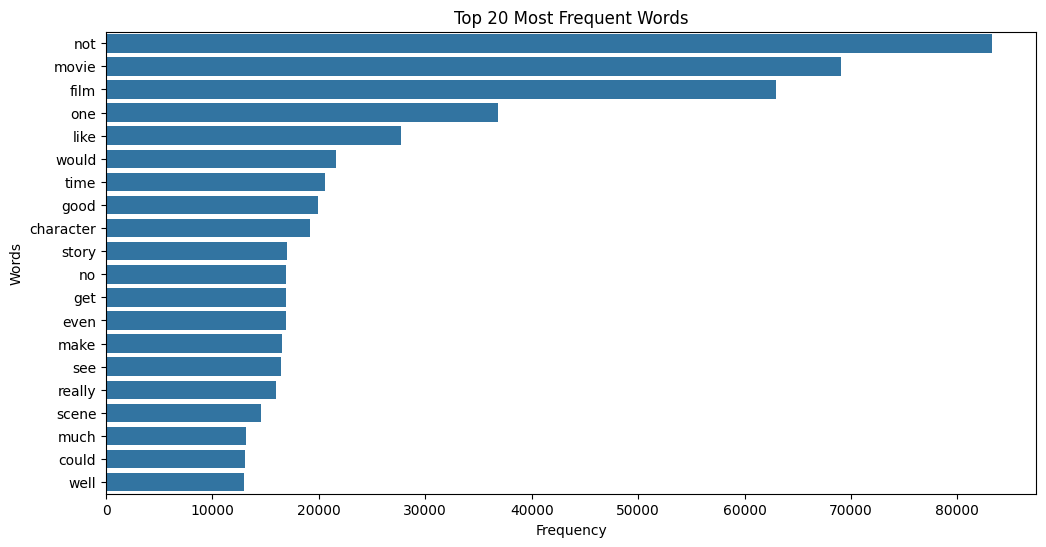

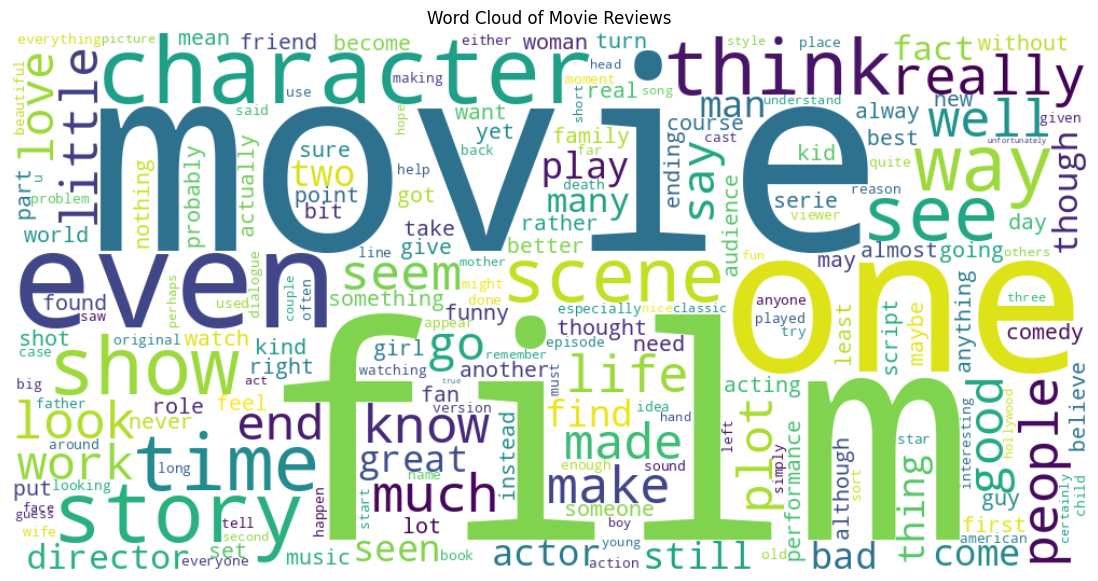

In [ ]:
# Install wordcloud
!pip install wordcloud

# Import libraries
from collections import Counter
from wordcloud import WordCloud

# Combine all cleaned reviews into one text
all_text = " ".join(train_df.clean_review.astype(str))

# Split text into words
words = all_text.split()

# Count word frequencies
word_freq = Counter(words)

# Get top 20 frequent words
top_words = word_freq.most_common(20)

# Convert into dataframe
freq_df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])

# Display dataframe
print(freq_df)

# Plot top frequent words
plt.figure(figsize=(12,6))

sns.barplot(
    x='Frequency',
    y='Word',
    data=freq_df
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

# Generate word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_text)

# Display word cloud
plt.figure(figsize=(15,7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Word Cloud of Movie Reviews")

plt.show()

STEP 4 — Tokenization and Sequence Padding

In [ ]:

# Import libraries
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Define vocabulary size
vocab_size = 9000

# Create tokenizer
tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

# Fit tokenizer on training data
tokenizer.fit_on_texts(train_df['clean_review'])

# Convert text into sequences
X_train = tokenizer.texts_to_sequences(train_df['clean_review'])

X_val = tokenizer.texts_to_sequences(val_df['clean_review'])

X_test = tokenizer.texts_to_sequences(test_df['clean_review'])

# Calculate sequence lengths
sequence_lengths = [len(seq) for seq in X_train]

# Analyze sequence statistics
print("Maximum sequence length :", max(sequence_lengths))

print("Average sequence length :", np.mean(sequence_lengths))

# Use percentile-based max length
max_length = int(np.percentile(sequence_lengths, 95))

print("Chosen max sequence length :", max_length)

# Apply padding
X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_val = pad_sequences(
    X_val,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

# Target labels
y_train = train_df['sentiment'].values

y_val = val_df['sentiment'].values

y_test = test_df['sentiment'].values

# Display shapes
print("\nTRAIN SHAPE :", X_train.shape)

print("VALIDATION SHAPE :", X_val.shape)

print("TEST SHAPE :", X_test.shape)

# Vocabulary size learned
actual_vocab_size = len(tokenizer.word_index)

print("\nActual Vocabulary Size :", actual_vocab_size)

# Example sequence
print("\nSample Tokenized Sequence :")

print(X_train[0])

# Word index example
print("\nTokenizer Word Index Sample :")

for word, index in list(tokenizer.word_index.items())[:10]:

    print(f"{word} --> {index}")

Maximum sequence length : 1421
Average sequence length : 119.04708571428571
Chosen max sequence length : 306

TRAIN SHAPE : (35000, 306)
VALIDATION SHAPE : (5000, 306)
TEST SHAPE : (10000, 306)

Actual Vocabulary Size : 160019

Sample Tokenized Sequence :
[3912  204    3  320 2420  164  211    1   35    2  382   19  475  168
   13    1    1    1 1753 1753    1    6    1    6  237   80    1    4
  271  705   28   44    6  113  462 1052  232  237    1  774    5   77
   12 6077  634  363 2244 5123 1693  900  164 1090  143  242  410   50
  182  634 4681 1954 1555  793  298 2543  746  126  126  363    7    1
 3367 4556  462    1   16    1   63   14   15  521    1  991 2125  462
 1563  227 1906   51 4557 1586  654   68  131    1  257 3244  592 2967
 1679 3600 4865  977  283    1 1883  193  257   63  406  596    6   25
 4114    5   42 3484  250  121 4115   10   14  331 7412  227    1  310
 3510    1    4 2142   47 3123  164 2470 2592 3230   81    1   17 3693
 2142  485 2372    1  152    0    

STEP 5 CODE — SIMPLE RNN MODEL

In [ ]:
# Import libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Build Simple RNN model
rnn_model = Sequential()

# Embedding layer
rnn_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    )
)

# Simple RNN layer
rnn_model.add(
    SimpleRNN(
        64,
        activation='tanh'
    )
)

# Dropout layer
rnn_model.add(
    Dropout(0.5)
)

# Output layer
rnn_model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

# Display model summary
rnn_model.summary()

# Compile model
rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Train model
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

# Evaluate model
rnn_loss, rnn_accuracy = rnn_model.evaluate(X_test, y_test)

print("\nRNN Test Accuracy :", rnn_accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 76s 135ms/step - accuracy: 0.5009 - loss: 0.6983 - val_accuracy: 0.4952 - val_loss: 0.6939
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 74s 135ms/step - accuracy: 0.5207 - loss: 0.6875 - val_accuracy: 0.4930 - val_loss: 0.6929
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 80s 131ms/step - accuracy: 0.5237 - loss: 0.7023 - val_accuracy: 0.4926 - val_loss: 0.6941
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 72s 131ms/step - accuracy: 0.5014 - loss: 0.6982 - val_accuracy: 0.4998 - val_loss: 0.6935
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.4968 - loss: 0.6932

RNN Test Accuracy : 0.4968000054359436


In [ ]:
import pickle

# Save RNN history
with open(
    "/content/drive/MyDrive/history_rnn.pkl",
    "wb"
) as file:

    pickle.dump(
        history_rnn.history,
        file
    )

STEP 6 — RNN Evaluation & Visualization

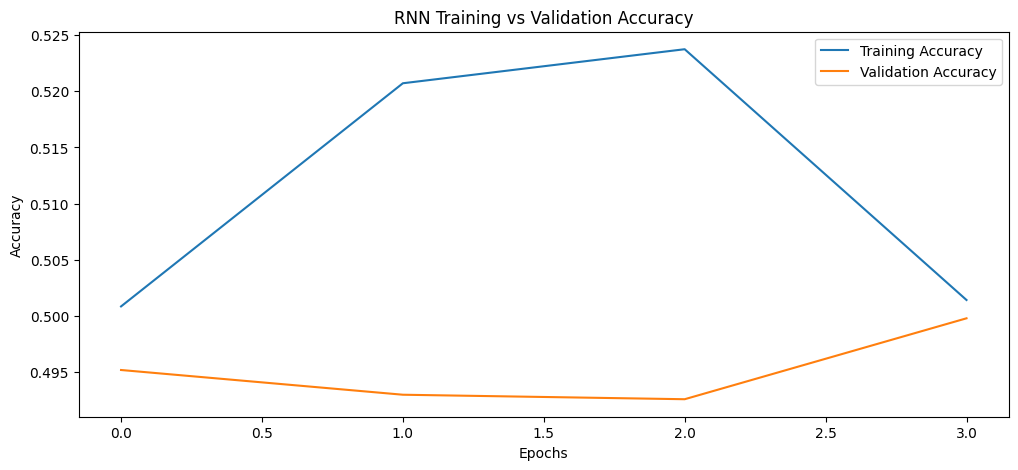

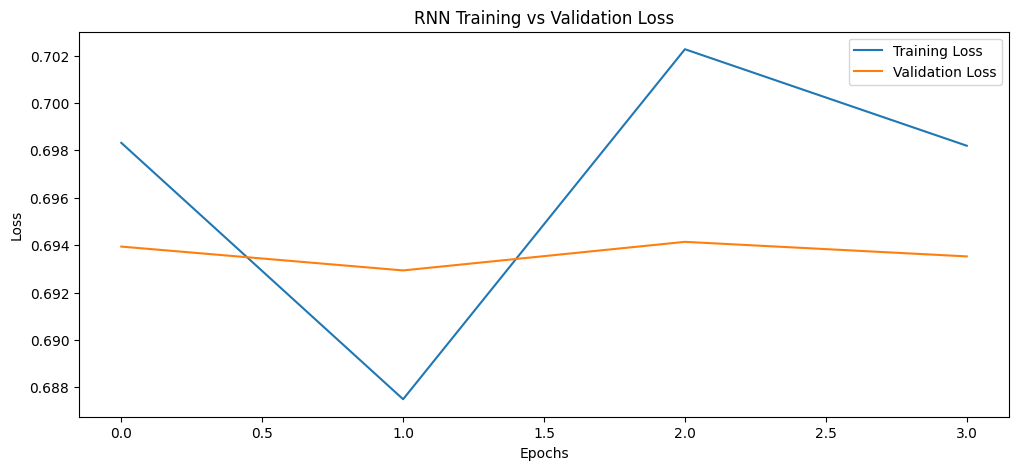

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       0.50      0.90      0.64      4961
           1       0.50      0.10      0.17      5039

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.41     10000
weighted avg       0.50      0.50      0.40     10000



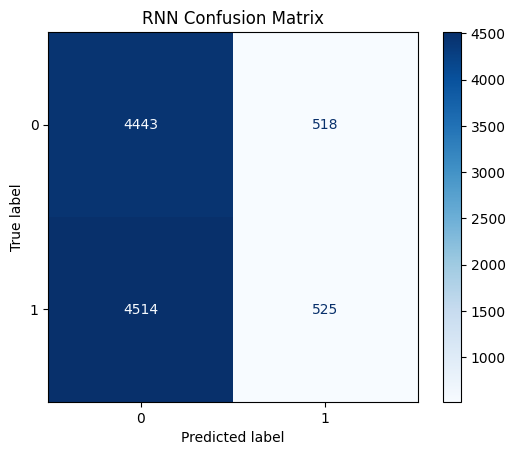


SAMPLE PREDICTIONS:

Review : I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ev
Actual Sentiment : 1
Predicted Sentiment : 0
--------------------------------------------------------------------------------
Review : Not many television shows appeal to quite as many different kinds of fans like Farscape does...I know youngsters and 30/40+ years old;fans both Male and Female in as many different countries as you ca
Actual Sentiment : 1
Predicted Sentiment : 0
--------------------------------------------------------------------------------
Review : The film quickly gets to a major chase scene with ever increasing destruction. The first really bad thing is the guy hijacking Steven Seagal would have been beaten to pulp by Seagal's driving, but tha
Actual Sentiment : 0
Predicted Sentiment : 0
---------------------------------------------------

In [ ]:
# Import libraries
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Plot training & validation accuracy
plt.figure(figsize=(12,5))

plt.plot(
    history_rnn.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_rnn.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("RNN Training vs Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

# Plot training & validation loss
plt.figure(figsize=(12,5))

plt.plot(
    history_rnn.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_rnn.history['val_loss'],
    label='Validation Loss'
)

plt.title("RNN Training vs Validation Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.show()

# Predict probabilities
y_pred_prob = rnn_model.predict(X_test)

# Convert probabilities into binary predictions
y_pred = (y_pred_prob > 0.5).astype(int)

# Classification report
print("\nCLASSIFICATION REPORT:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap='Blues')

plt.title("RNN Confusion Matrix")

plt.show()

# Display sample predictions
print("\nSAMPLE PREDICTIONS:\n")

for i in range(5):

    print("Review :", test_df['review'].iloc[i][:200])

    print("Actual Sentiment :", y_test[i])

    print("Predicted Sentiment :", y_pred[i][0])

    print("-" * 80)

STEP 7 — MODEL 2 (LSTM with Trainable Embedding)

In [ ]:
# Import libraries
from tensorflow.keras.layers import LSTM

# Build LSTM model
lstm_model = Sequential()

# Embedding layer
lstm_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    )
)

# LSTM layer
lstm_model.add(
    LSTM(
        64
    )
)

# Dropout layer
lstm_model.add(
    Dropout(0.5)
)

# Output layer
lstm_model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

# Display model summary
lstm_model.summary()

# Compile model
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Early stopping
early_stop_lstm = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Train model
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop_lstm]
)

# Evaluate model
lstm_loss, lstm_accuracy = lstm_model.evaluate(
    X_test,
    y_test
)

print("\nLSTM Test Accuracy :", lstm_accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 208s 375ms/step - accuracy: 0.5069 - loss: 0.6935 - val_accuracy: 0.4952 - val_loss: 0.6932
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 203s 371ms/step - accuracy: 0.5130 - loss: 0.6906 - val_accuracy: 0.5010 - val_loss: 0.6914
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 203s 371ms/step - accuracy: 0.5148 - loss: 0.6956 - val_accuracy: 0.5020 - val_loss: 0.6923
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 203s 371ms/step - accuracy: 0.5259 - loss: 0.6717 - val_accuracy: 0.5190 - val_loss: 0.6947
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.5061 - loss: 0.6900

LSTM Test Accuracy : 0.5060999989509583


In [ ]:
# Save LSTM history
with open(
    "/content/drive/MyDrive/history_lstm.pkl",
    "wb"
) as file:

    pickle.dump(
        history_lstm.history,
        file
    )


STEP 8 — LSTM Evaluation & Visualization

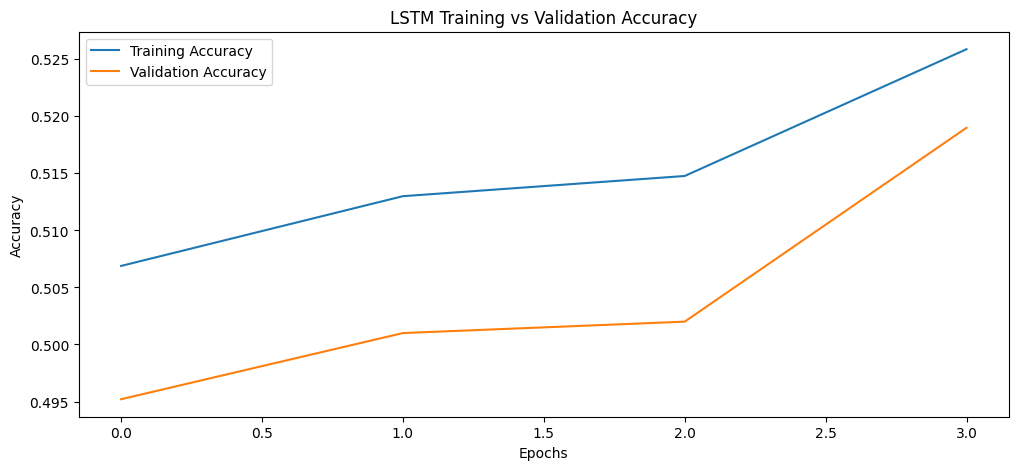

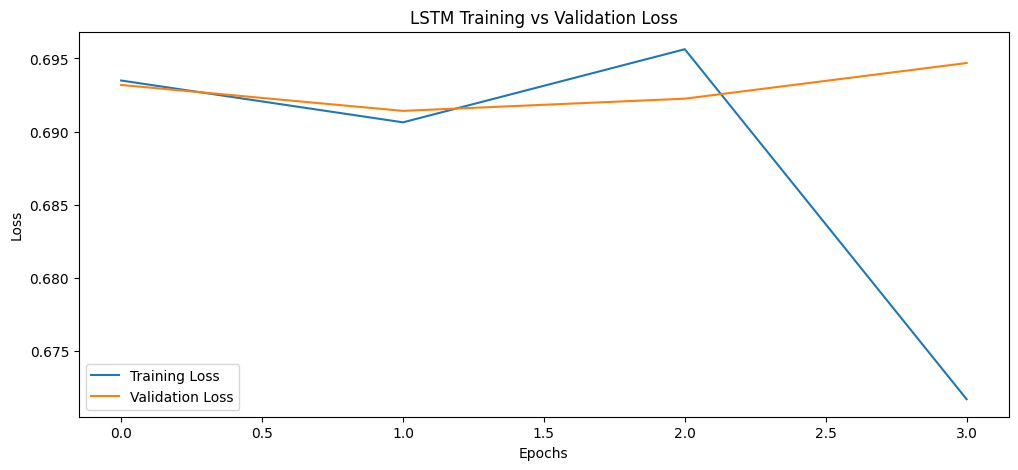

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step

LSTM CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       0.50      0.96      0.66      4961
           1       0.61      0.05      0.10      5039

    accuracy                           0.51     10000
   macro avg       0.56      0.51      0.38     10000
weighted avg       0.56      0.51      0.38     10000



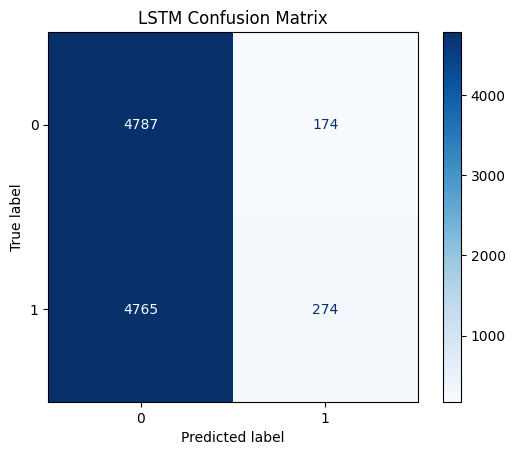


LSTM SAMPLE PREDICTIONS:

Review : I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ev
Actual Sentiment : 1
Predicted Sentiment : 0
--------------------------------------------------------------------------------
Review : Not many television shows appeal to quite as many different kinds of fans like Farscape does...I know youngsters and 30/40+ years old;fans both Male and Female in as many different countries as you ca
Actual Sentiment : 1
Predicted Sentiment : 0
--------------------------------------------------------------------------------
Review : The film quickly gets to a major chase scene with ever increasing destruction. The first really bad thing is the guy hijacking Steven Seagal would have been beaten to pulp by Seagal's driving, but tha
Actual Sentiment : 0
Predicted Sentiment : 0
----------------------------------------------

In [ ]:
# Import libraries
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Plot training & validation accuracy
plt.figure(figsize=(12,5))

plt.plot(
    history_lstm.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_lstm.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("LSTM Training vs Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

# Plot training & validation loss
plt.figure(figsize=(12,5))

plt.plot(
    history_lstm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_lstm.history['val_loss'],
    label='Validation Loss'
)

plt.title("LSTM Training vs Validation Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.show()

# Predict probabilities
y_pred_prob_lstm = lstm_model.predict(X_test)

# Convert probabilities into binary predictions
y_pred_lstm = (y_pred_prob_lstm > 0.5).astype(int)

# Classification report
print("\nLSTM CLASSIFICATION REPORT:\n")

print(
    classification_report(
        y_test,
        y_pred_lstm
    )
)

# Confusion matrix
cm_lstm = confusion_matrix(
    y_test,
    y_pred_lstm
)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm
)

disp.plot(cmap='Blues')

plt.title("LSTM Confusion Matrix")

plt.show()

# Display sample predictions
print("\nLSTM SAMPLE PREDICTIONS:\n")

for i in range(5):

    print("Review :", test_df['review'].iloc[i][:200])

    print("Actual Sentiment :", y_test[i])

    print("Predicted Sentiment :", y_pred_lstm[i][0])

    print("-" * 80)

STEP 9 CODE — WORD2VEC + LSTM

In [ ]:
# Install gensim
!pip install gensim

# Import libraries
import gensim.downloader as api

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# Load pretrained embeddings
embedding_model = api.load('glove-wiki-gigaword-100')

print("Pretrained embeddings loaded!")

# Embedding dimension
embedding_dim = 100

# Create embedding matrix
embedding_matrix = np.zeros(
    (vocab_size, embedding_dim)
)

# Build embedding matrix
for word, index in tokenizer.word_index.items():

    if index < vocab_size:

        if word in embedding_model:

            embedding_matrix[index] = embedding_model[word]

# Build improved model
word2vec_bilstm_model = Sequential()

# Pretrained embedding layer
word2vec_bilstm_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )
)

# Bidirectional LSTM
word2vec_bilstm_model.add(
    Bidirectional(
        LSTM(
            64,
            return_sequences=False
        )
    )
)

# Dropout
word2vec_bilstm_model.add(
    Dropout(0.5)
)

# Dense hidden layer
word2vec_bilstm_model.add(
    Dense(
        32,
        activation='relu'
    )
)

# Output layer
word2vec_bilstm_model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

# Model summary
word2vec_bilstm_model.summary()

# Compile model
word2vec_bilstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Train model
history_w2v = word2vec_bilstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

# Evaluate model
loss, accuracy = word2vec_bilstm_model.evaluate(
    X_test,
    y_test
)

print("\nWord2Vec BiLSTM Accuracy :", accuracy)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 24.8 MB/s eta 0:00:00
[==================================================] 100.0% 128.1/128.1MB downloaded
Pretrained embeddings loaded!


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       900,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 900,000 (3.43 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 900,000 (3.43 MB)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 285s 513ms/step - accuracy: 0.7273 - loss: 0.5439 - val_accuracy: 0.7376 - val_loss: 0.5652
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 321s 511ms/step - accuracy: 0.8168 - loss: 0.4188 - val_accuracy: 0.8454 - val_loss: 0.3670
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 280s 511ms/step - accuracy: 0.8462 - loss: 0.3639 - val_accuracy: 0.8490 - val_loss: 0.3482
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 287s 524ms/step - accuracy: 0.8619 - loss: 0.3321 - val_accuracy: 0.8610 - val_loss: 0.3205
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 280s 513ms/step - accuracy: 0.8709 - loss: 0.3136 - val_accuracy: 0.8704 - val_loss: 0.3129
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 322s 512ms/step - accuracy: 0.8803 - loss: 0.2927 - val_accuracy: 0.8728 - val_loss: 0.2988
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 279s 511ms/step - accuracy: 0.8885 - loss: 0.2769 - val_accuracy: 0.8780 - val_loss: 0.2964
Epoch 8/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 285s 521ms/step - accuracy: 0.8938 -

In [ ]:
# Save Word2Vec history
with open(
    "/content/drive/MyDrive/history_w2v.pkl",
    "wb"
) as file:

    pickle.dump(
        history_w2v.history,
        file
    )

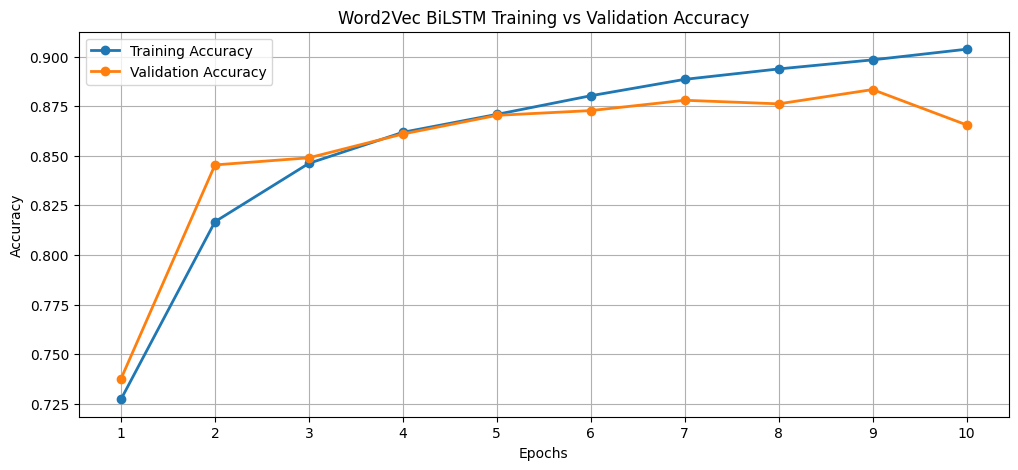

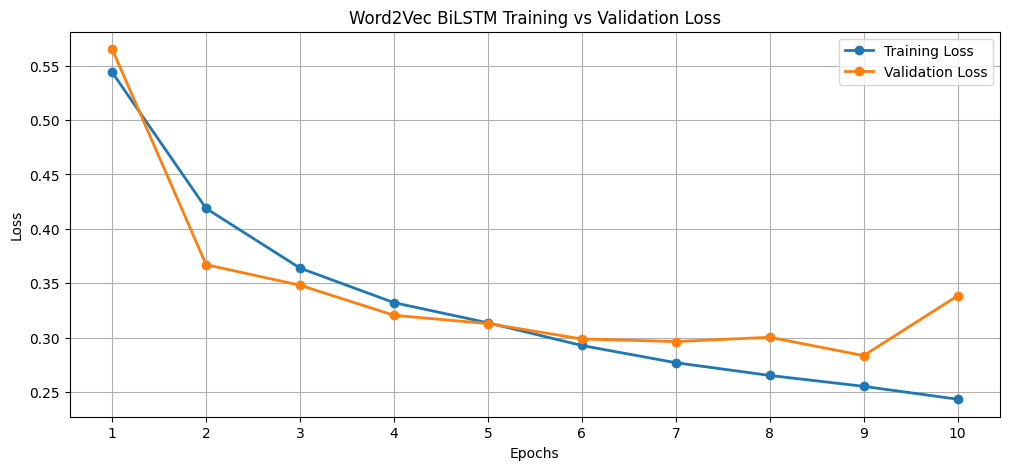

313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 83ms/step

WORD2VEC BILSTM CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       0.88      0.87      0.88      4961
           1       0.87      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



<Figure size 600x600 with 0 Axes>

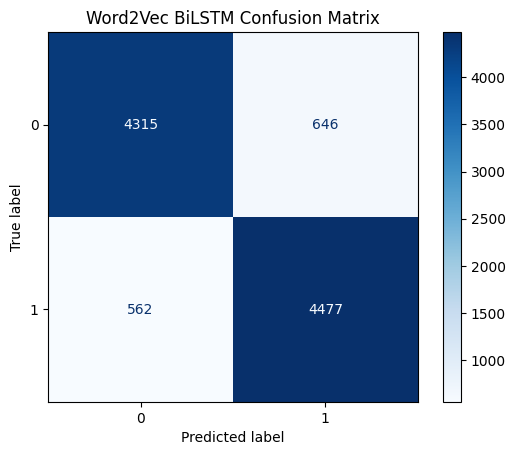


SAMPLE PREDICTIONS:

Review :
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main ev

Actual Sentiment : 1
Predicted Sentiment : 0
----------------------------------------------------------------------------------------------------
Review :
Not many television shows appeal to quite as many different kinds of fans like Farscape does...I know youngsters and 30/40+ years old;fans both Male and Female in as many different countries as you can think of that just adore this T.V miniseries. It

Actual Sentiment : 1
Predicted Sentiment : 1
----------------------------------------------------------------------------------------------------
Review :
The film quickly gets to a major chase scene with ever increasing destruction. The first really bad thing is the guy hijacking Steven Seagal would have bee

In [ ]:
# Import libraries
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Epoch range
epochs = range(
    1,
    len(history_w2v.history['accuracy']) + 1
)

# Plot training and validation accuracy
plt.figure(figsize=(12,5))

plt.plot(
    epochs,
    history_w2v.history['accuracy'],
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    epochs,
    history_w2v.history['val_accuracy'],
    marker='o',
    linewidth=2,
    label='Validation Accuracy'
)

plt.title(
    "Word2Vec BiLSTM Training vs Validation Accuracy"
)

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.xticks(epochs)

plt.grid(True)

plt.legend()

plt.show()

# Plot training and validation loss
plt.figure(figsize=(12,5))

plt.plot(
    epochs,
    history_w2v.history['loss'],
    marker='o',
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    epochs,
    history_w2v.history['val_loss'],
    marker='o',
    linewidth=2,
    label='Validation Loss'
)

plt.title(
    "Word2Vec BiLSTM Training vs Validation Loss"
)

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.xticks(epochs)

plt.grid(True)

plt.legend()

plt.show()

# Predict probabilities
y_pred_prob_w2v = word2vec_bilstm_model.predict(
    X_test
)

# Convert probabilities to binary predictions
y_pred_w2v = (
    y_pred_prob_w2v > 0.5
).astype(int)

# Classification report
print(
    "\nWORD2VEC BILSTM CLASSIFICATION REPORT:\n"
)

print(
    classification_report(
        y_test,
        y_pred_w2v
    )
)

# Confusion matrix
cm_w2v = confusion_matrix(
    y_test,
    y_pred_w2v
)

# Plot confusion matrix
plt.figure(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_w2v
)

disp.plot(cmap='Blues')

plt.title(
    "Word2Vec BiLSTM Confusion Matrix"
)

plt.grid(False)

plt.show()

# Sample predictions
print("\nSAMPLE PREDICTIONS:\n")

for i in range(5):

    print("Review :")

    print(
        test_df['review'].iloc[i][:250]
    )

    print(
        "\nActual Sentiment :",
        y_test[i]
    )

    print(
        "Predicted Sentiment :",
        y_pred_w2v[i][0]
    )

    print("-" * 100)

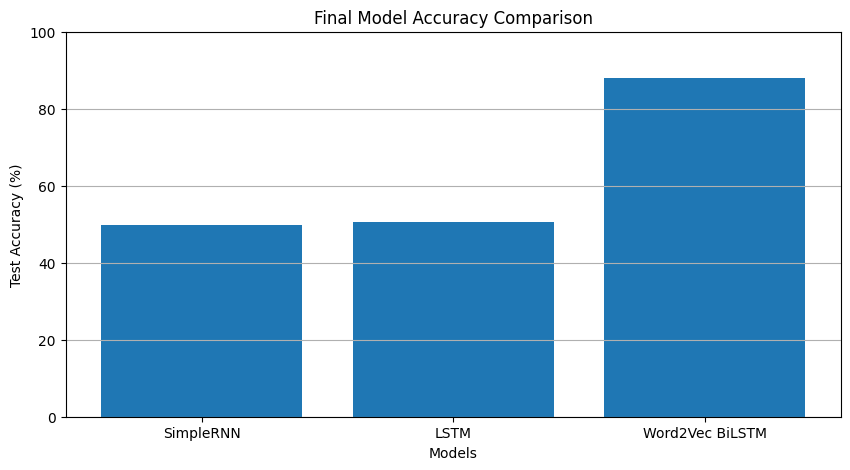

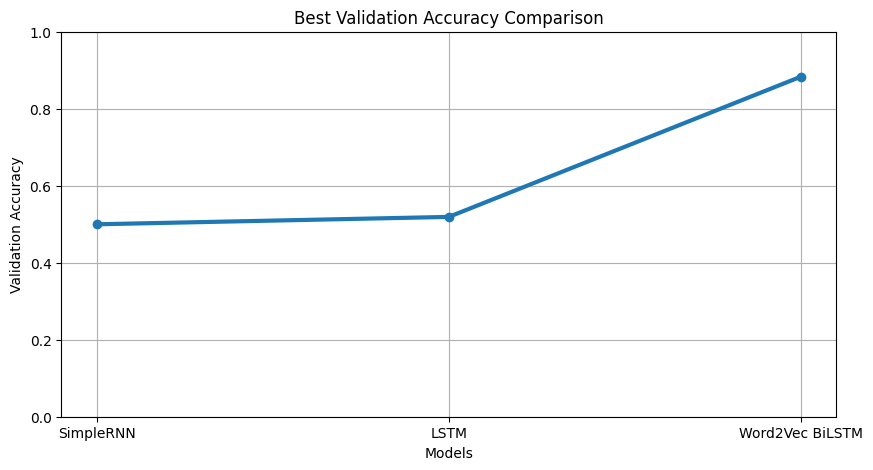

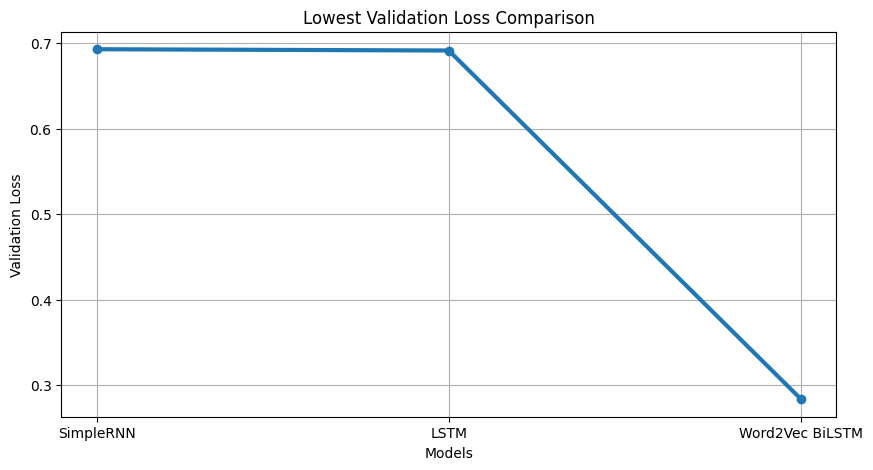


FINAL MODEL COMPARISON:

SimpleRNN --> Test Accuracy : 49.68%
LSTM --> Test Accuracy : 50.61%
Word2Vec BiLSTM --> Test Accuracy : 87.92%


In [ ]:
# Model names
models = [
    'SimpleRNN',
    'LSTM',
    'Word2Vec BiLSTM'
]

# Final test accuracies
accuracies = [
    49.68,
    50.61,
    87.92
]

# Accuracy comparison graph
plt.figure(figsize=(10,5))

plt.bar(
    models,
    accuracies
)

plt.title(
    "Final Model Accuracy Comparison"
)

plt.xlabel("Models")

plt.ylabel("Test Accuracy (%)")

plt.ylim(0,100)

plt.grid(axis='y')

plt.show()


# Best validation accuracies
best_val_acc = [
    max(history_rnn.history['val_accuracy']),
    max(history_lstm.history['val_accuracy']),
    max(history_w2v.history['val_accuracy'])
]

# Validation accuracy comparison graph
plt.figure(figsize=(10,5))

plt.plot(
    models,
    best_val_acc,
    marker='o',
    linewidth=3
)

plt.title(
    "Best Validation Accuracy Comparison"
)

plt.xlabel("Models")

plt.ylabel("Validation Accuracy")

plt.ylim(0,1)

plt.grid(True)

plt.show()


# Lowest validation losses
best_val_loss = [
    min(history_rnn.history['val_loss']),
    min(history_lstm.history['val_loss']),
    min(history_w2v.history['val_loss'])
]

# Validation loss comparison graph
plt.figure(figsize=(10,5))

plt.plot(
    models,
    best_val_loss,
    marker='o',
    linewidth=3
)

plt.title(
    "Lowest Validation Loss Comparison"
)

plt.xlabel("Models")

plt.ylabel("Validation Loss")

plt.grid(True)

plt.show()


# Print final comparison summary
print("\nFINAL MODEL COMPARISON:\n")

for i in range(len(models)):

    print(
        f"{models[i]} --> "
        f"Test Accuracy : {accuracies[i]}%"
    )

In [ ]:
!pip install gradio

import gradio as gr
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Prediction function
def predict_sentiment(review):

    # Clean review
    cleaned = clean_text(review)

    # Convert to sequence
    sequence = tokenizer.texts_to_sequences(
        [cleaned]
    )

    # Pad sequence
    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post'
    )

    # Predict
    prediction = word2vec_bilstm_model.predict(
        padded
    )[0][0]

    # Output label
    if prediction >= 0.5:

        return (
            f"Positive Sentiment "
            f"({prediction:.2f})"
        )

    else:

        return (
            f"Negative Sentiment "
            f"({prediction:.2f})"
        )

# Create interface
interface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter movie review here..."
    ),
    outputs="text",
    title="Movie Review Sentiment Analysis",
    description="Predict movie review sentiment using Word2Vec BiLSTM"
)

# Launch interface
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ff7b1e3e81c4699c21.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
